# AI CV Personality Analyzer
## 01 - Dataset Exploration

### Project Overview

This project develops an AI-powered CV analysis system that uses
Natural Language Processing (NLP) and Machine Learning to predict
Big Five personality traits from resume/CV content.

The five personality dimensions are:

- **O — Openness**
- **C — Conscientiousness**
- **E — Extraversion**
- **A — Agreeableness**
- **N — Neuroticism**

The system will later use these learned personality patterns to
analyze newly uploaded CVs dynamically.

### Objective of This Notebook

In this notebook, we will:

1. Load the training, validation, and test datasets.
2. Understand the dataset structure.
3. Inspect columns and data types.
4. Check dataset sizes.
5. Check missing values.
6. Check duplicate records.
7. Analyze personality target distributions.
8. Inspect text data.
9. Identify potential data-quality issues.
10. Summarize the findings for the next preprocessing stage.

> **Note:** No data preprocessing or model training is performed in this notebook.

## 1. Import Required Libraries

We begin by importing the libraries required for dataset exploration,
data analysis, and visualization.

In [48]:
# Import pandas for data loading and DataFrame operations
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Import matplotlib for visualizations
import matplotlib.pyplot as plt

# Import seaborn for statistical visualizations
import seaborn as sns

# Display plots directly inside the notebook
%matplotlib inline

# Set a clean plotting style for exploratory analysis
sns.set_theme(style="whitegrid")

# Display all columns when printing DataFrames
pd.set_option("display.max_columns", None)

# Increase the maximum width used when displaying DataFrames
pd.set_option("display.width", 120)

In [49]:
# Define the paths to the three dataset files.
# The notebook is inside the "notebooks" folder,
# therefore "../data/raw/" points to the raw dataset directory.

TRAIN_PATH = "../data/raw/train.parquet"
VALIDATION_PATH = "../data/raw/validation.parquet"
TEST_PATH = "../data/raw/test.parquet"

# Load the Parquet files into pandas DataFrames
train_df = pd.read_parquet(TRAIN_PATH)
validation_df = pd.read_parquet(VALIDATION_PATH)
test_df = pd.read_parquet(TEST_PATH)

# Confirm that all datasets were loaded successfully
print("Datasets loaded successfully.")

Datasets loaded successfully.


## 3. Dataset Size

Let's check the number of rows and columns in each dataset.

The shape is represented as:

`(number of rows, number of columns)`

In [50]:
# Display the shape of each dataset

print("Dataset Shapes")
print("-" * 40)

print(f"Training Set   : {train_df.shape}")
print(f"Validation Set : {validation_df.shape}")
print(f"Test Set       : {test_df.shape}")

# Calculate the total number of records
total_records = len(train_df) + len(validation_df) + len(test_df)

print("-" * 40)
print(f"Total Records  : {total_records}")

Dataset Shapes
----------------------------------------
Training Set   : (1578, 8)
Validation Set : (395, 8)
Test Set       : (494, 8)
----------------------------------------
Total Records  : 2467


## 4. Dataset Columns

Let's inspect all columns available in the dataset.

We expect personality-related columns such as:

- O — Openness
- C — Conscientiousness
- E — Extraversion
- A — Agreeableness
- N — Neuroticism
- ptype — personality type/category information
- text — textual input

The actual columns will be confirmed from the dataset rather than assumed.

## 4.1 Dataset Index Column

The dataset contains an additional column named `__index_level_0__`.

This column represents the original row/index information from the source
dataset and does not contain meaningful personality or text information.

It will therefore be excluded from the Machine Learning features during
the preprocessing stage.

In [51]:
# Display the column names of the training dataset

print("Training Dataset Columns")
print("-" * 40)

for index, column in enumerate(train_df.columns, start=1):
    print(f"{index}. {column}")

Training Dataset Columns
----------------------------------------
1. O
2. C
3. E
4. A
5. N
6. ptype
7. text
8. __index_level_0__


## 5. Preview the Dataset

Let's inspect the first few records to understand how the data is structured.

This helps us understand:

- What the text looks like.
- How personality labels are represented.
- Whether the dataset contains unexpected values.

In [52]:
# Display the first five rows of the training dataset

display(train_df.head())

,O,C,E,A,N,ptype,text,__index_level_0__
0,1,0,0,1,1,19,it is wednesday. I can't wait until friday bec...,774
1,1,1,1,0,1,29,"wow, I want to go talk to the socialist organi...",178
2,1,0,1,1,0,22,"I wish polygamy was still legal. Well, not pol...",1881
3,1,0,1,0,0,20,"Well, lets see . . . I guess the foremost thin...",1563
4,0,1,0,1,1,11,College? I wonder how it will be? I just ...,1594


## 6. Random Sample

The first rows alone may not represent the complete dataset.

Therefore, we also inspect random records to understand
different examples present in the dataset.

In [53]:
# Display five randomly selected records

display(train_df.sample(5, random_state=42))

,O,C,E,A,N,ptype,text,__index_level_0__
1239,0,0,1,1,0,6,"I have a stuffy head and runny nose, and I hav...",732
813,0,0,0,0,0,0,Got a Beatles play list going in Winamp. Lucy ...,2295
1174,1,1,1,1,0,30,"I really like music, i think its really c...",1654
534,0,0,1,1,1,7,"My roommate is trying to sleep, so I hope that...",141
514,0,1,0,1,1,11,I guess I'll just start out by explaining how ...,1462


## 7. Data Types and Dataset Information

Next, we inspect:

- Column data types
- Number of non-null values
- Memory usage
- Dataset structure

This helps identify columns that may require conversion or cleaning
during the preprocessing stage.

In [54]:
# Display detailed information about the training dataset

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1578 entries, 0 to 1577
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   O                  1578 non-null   object
 1   C                  1578 non-null   object
 2   E                  1578 non-null   object
 3   A                  1578 non-null   object
 4   N                  1578 non-null   object
 5   ptype              1578 non-null   object
 6   text               1578 non-null   object
 7   __index_level_0__  1578 non-null   int64 
dtypes: int64(1), object(7)
memory usage: 98.8+ KB


## 8. Statistical Summary

Let's generate a statistical summary of the dataset.

For numerical columns, this includes:

- Count
- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

For categorical/text columns, numerical statistics may not be available.

In [55]:
# Display statistical information for numerical columns

display(train_df.describe())

,__index_level_0__
count,1578.00000
mean,1225.58365
std,714.11486
min,2.00000
25%,589.25000
50%,1225.50000
75%,1844.50000
max,2466.00000


## 9. Missing Value Analysis

Missing values can negatively affect Machine Learning models.

We will check the number and percentage of missing values
in every column.

In [56]:
# Calculate the number of missing values in each column
missing_count = train_df.isnull().sum()

# Calculate the percentage of missing values in each column
missing_percentage = (missing_count / len(train_df)) * 100

# Combine both results into a single DataFrame
missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage
})

# Sort columns by the number of missing values
missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

# Display the missing value summary
display(missing_summary)

,Missing Values,Missing Percentage
O,0,0.0
C,0,0.0
E,0,0.0
A,0,0.0
N,0,0.0
ptype,0,0.0
text,0,0.0
__index_level_0__,0,0.0


## 10. Duplicate Record Analysis

Duplicate records can cause data leakage or give excessive importance
to repeated examples.

Let's check whether duplicate rows are present.

In [57]:
# Count completely duplicated rows
duplicate_count = train_df.duplicated().sum()

# Calculate duplicate percentage
duplicate_percentage = (duplicate_count / len(train_df)) * 100

print(f"Duplicate Rows      : {duplicate_count}")
print(f"Duplicate Percentage: {duplicate_percentage:.2f}%")

Duplicate Rows      : 0
Duplicate Percentage: 0.00%


## 11. Personality Target Columns

The Big Five personality dimensions are represented by:

- **O** → Openness
- **C** → Conscientiousness
- **E** → Extraversion
- **A** → Agreeableness
- **N** → Neuroticism

Before building the Machine Learning model, we need to understand
how these target values are represented.

For example, they may be binary classes such as 0/1.

In [58]:
# Define the expected Big Five personality columns
personality_columns = ["O", "C", "E", "A", "N"]

# Check which personality columns actually exist in the dataset
available_personality_columns = [
    column for column in personality_columns
    if column in train_df.columns
]

print("Available Personality Columns:")
print(available_personality_columns)

Available Personality Columns:
['O', 'C', 'E', 'A', 'N']


## 12. Personality Target Distribution

Let's inspect the unique values and frequency distribution
for each Big Five personality target.

This is important for identifying:

- Binary classification
- Multi-class classification
- Class imbalance
- Unexpected values

## 12.1 Target Variable Findings

The Big Five personality traits are represented as binary labels:

- **O** — Openness
- **C** — Conscientiousness
- **E** — Extraversion
- **A** — Agreeableness
- **N** — Neuroticism

Each target contains two classes:

- `0`
- `1`

The labels are stored as strings in the raw dataset and will be converted
to integer values during preprocessing.

The class distributions are relatively balanced across the five traits,
which is favorable for binary classification.

The model will independently predict each of the five personality traits.

In [59]:
# Display unique values and their frequencies
# for each available personality trait

for column in available_personality_columns:

    print("\n" + "=" * 50)
    print(f"Personality Trait: {column}")
    print("=" * 50)

    print("Unique Values:")
    print(train_df[column].unique())

    print("\nValue Counts:")
    print(train_df[column].value_counts(dropna=False))


Personality Trait: O
Unique Values:
['1' '0']

Value Counts:
O
1    813
0    765
Name: count, dtype: int64

Personality Trait: C
Unique Values:
['0' '1']

Value Counts:
C
1    802
0    776
Name: count, dtype: int64

Personality Trait: E
Unique Values:
['0' '1']

Value Counts:
E
1    817
0    761
Name: count, dtype: int64

Personality Trait: A
Unique Values:
['1' '0']

Value Counts:
A
1    837
0    741
Name: count, dtype: int64

Personality Trait: N
Unique Values:
['1' '0']

Value Counts:
N
0    790
1    788
Name: count, dtype: int64


## 13. Visualize Personality Distribution

Visualizing the personality labels helps us quickly identify
whether the classes are balanced or imbalanced.

Balanced classes generally make classification easier,
while severe imbalance may require special handling during training.

## 13.1 Personality Class Balance

The following table shows the number and percentage of records belonging
to each class for every Big Five personality trait.

This helps identify potential class imbalance before model training.

In [60]:
# Create a summary table for Big Five class distributions

class_balance = []

for column in available_personality_columns:

    # Count records for each class
    counts = train_df[column].value_counts().sort_index()

    # Calculate class percentages
    percentages = train_df[column].value_counts(
        normalize=True
    ).sort_index() * 100

    # Store results
    for label in counts.index:
        class_balance.append({
            "Trait": column,
            "Class": label,
            "Count": counts[label],
            "Percentage": round(percentages[label], 2)
        })

# Convert results into a DataFrame
class_balance_df = pd.DataFrame(class_balance)

# Display the class-balance table
display(class_balance_df)

,Trait,Class,Count,Percentage
0,O,0,765,48.48
1,O,1,813,51.52
2,C,0,776,49.18
3,C,1,802,50.82
4,E,0,761,48.23
5,E,1,817,51.77
6,A,0,741,46.96
7,A,1,837,53.04
8,N,0,790,50.06
9,N,1,788,49.94


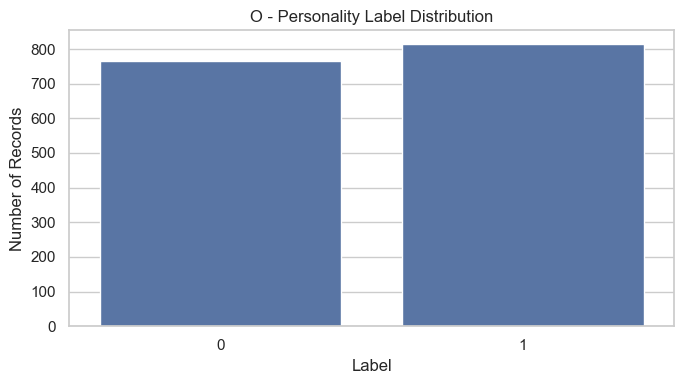

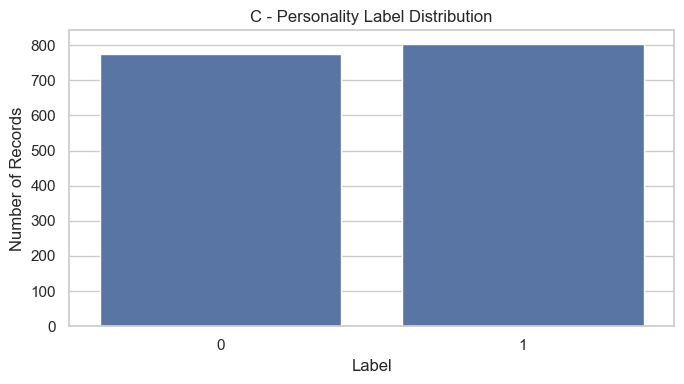

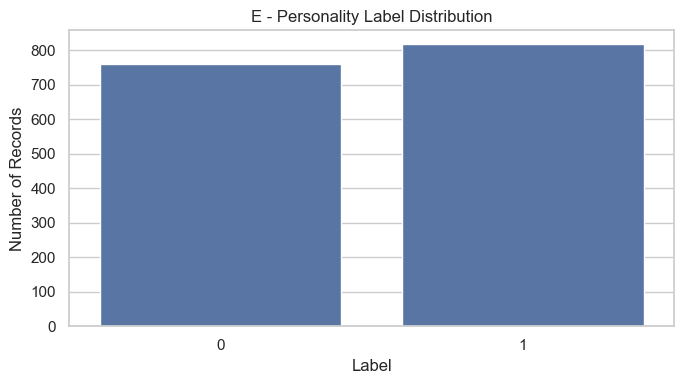

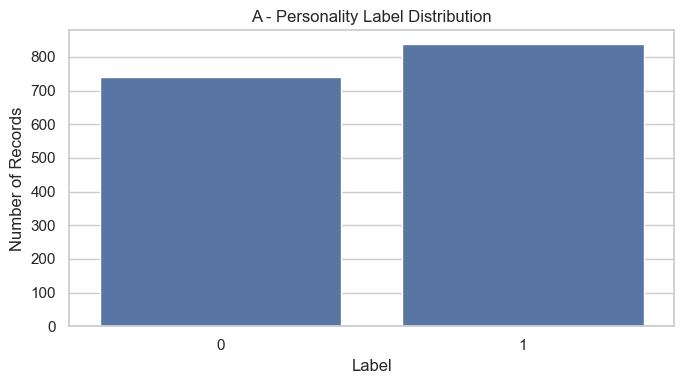

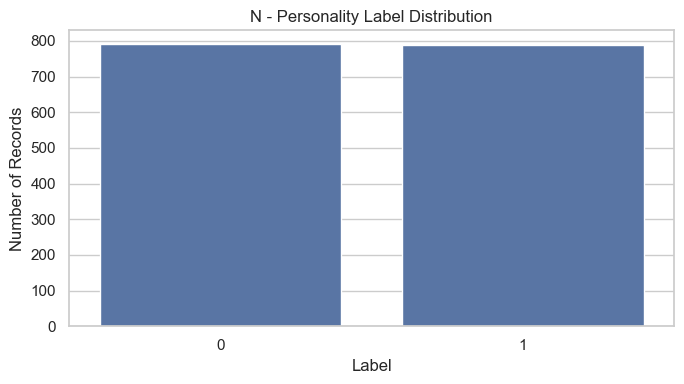

In [61]:
# Create one bar chart for each Big Five personality trait

for column in available_personality_columns:

    plt.figure(figsize=(7, 4))

    # Count the frequency of each personality label
    value_counts = train_df[column].value_counts().sort_index()

    # Create the bar chart
    sns.barplot(
        x=value_counts.index.astype(str),
        y=value_counts.values
    )

    # Add chart title and labels
    plt.title(f"{column} - Personality Label Distribution")
    plt.xlabel("Label")
    plt.ylabel("Number of Records")

    # Display the chart
    plt.tight_layout()
    plt.show()

## 14. Text Column Analysis

The text column is the main input for our NLP model.

We need to understand:

- Number of text records
- Missing text
- Empty text
- Text length
- Minimum text length
- Maximum text length
- Average text length

These statistics will help us design the preprocessing pipeline.

In [62]:
# Identify the text column automatically.
# The expected column is "text".

if "text" in train_df.columns:
    text_column = "text"
else:
    # Find possible text/object columns if "text" is not available
    object_columns = train_df.select_dtypes(
        include=["object", "string"]
    ).columns.tolist()

    print("Possible text columns:", object_columns)

    # Use the first object/string column as a fallback
    text_column = object_columns[0] if object_columns else None

print("Selected text column:", text_column)

Selected text column: text


In [63]:
# Make sure a text column was found before continuing

if text_column is not None:

    # Convert text values to strings temporarily for analysis
    text_series = train_df[text_column].fillna("").astype(str)

    # Calculate text length for every record
    text_lengths = text_series.str.len()

    print("Text Statistics")
    print("-" * 40)

    print(f"Number of Text Records : {len(text_series)}")
    print(f"Minimum Text Length    : {text_lengths.min()}")
    print(f"Maximum Text Length    : {text_lengths.max()}")
    print(f"Average Text Length    : {text_lengths.mean():.2f}")
    print(f"Median Text Length     : {text_lengths.median():.2f}")
else:
    print("No text column was found.")

Text Statistics
----------------------------------------
Number of Text Records : 1578
Minimum Text Length    : 217
Maximum Text Length    : 12852
Average Text Length    : 3314.89
Median Text Length     : 3171.00


## 15. Text Length Distribution

Text length is an important NLP characteristic.

Very short or extremely long documents may require special handling
during preprocessing and feature engineering.

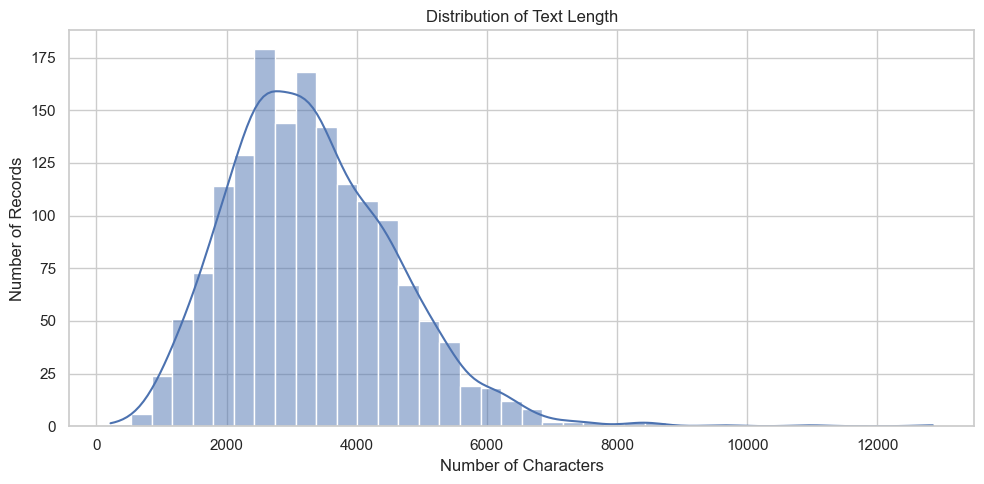

In [64]:
# Plot the distribution of text lengths

if text_column is not None:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        text_lengths,
        bins=40,
        kde=True
    )

    plt.title("Distribution of Text Length")
    plt.xlabel("Number of Characters")
    plt.ylabel("Number of Records")

    plt.tight_layout()
    plt.show()

## 16. Shortest and Longest Text Records

Let's inspect examples with very short and very long text.

This helps identify unusual records and possible data-quality problems.

In [65]:
# Display the shortest text records

if text_column is not None:

    print("Shortest Text Records")
    print("=" * 60)

    shortest_records = train_df.loc[
        text_lengths.nsmallest(3).index,
        [text_column]
    ]

    display(shortest_records)

    print("\nLongest Text Records")
    print("=" * 60)

    longest_records = train_df.loc[
        text_lengths.nlargest(3).index,
        [text_column]
    ]

    display(longest_records)

Shortest Text Records


,text
962,this job is going to drain me if I don't say s...
1509,Is there a reason? These questions have been ...
942,My roommate won't shut up. O. K. Bert. My frie...



Longest Text Records


,text
1381,I'm thinking about what I need to do befo...
726,Ok. I'm not sure what to write about. I guess....
122,I really don't konow waht to write about ...


## 17. Personality Type Column

The dataset may contain a `ptype` column representing an additional
personality category/type.

We will inspect it separately.

This column will not automatically be used as a prediction target.
We will decide its role during the preprocessing and modelling stages.

## 17.1 Personality Type and Data Leakage Consideration

The dataset contains a `ptype` column representing an additional
personality-related category.

Because `ptype` may contain information directly related to the
personality targets, using it as an input feature could introduce
data leakage.

Therefore, `ptype` will not be used as an input feature for the
initial personality prediction model.

The initial model will focus primarily on the CV/text content and
NLP-derived features.

In [66]:
# Check whether the "ptype" column exists

if "ptype" in train_df.columns:

    print("Personality Type Distribution")
    print("-" * 50)

    display(train_df["ptype"].value_counts(dropna=False))

else:

    print("'ptype' column is not available in the dataset.")

Personality Type Distribution
--------------------------------------------------


ptype
30    121
1      90
17     86
14     86
22     58
10     57
9      57
21     51
3      50
6      46
15     46
19     46
31     46
23     46
18     46
28     46
11     46
12     46
26     46
29     44
5      43
25     40
20     40
16     38
0      38
2      34
13     34
7      34
24     30
4      30
27     29
8      28
Name: count, dtype: int64

## 18. Dataset Split Verification

The dataset has predefined training, validation, and test sets.

We should confirm that all three splits contain the same columns.

Consistent columns are required before building the ML pipeline.

In [67]:
# Compare columns across all three dataset splits

train_columns = set(train_df.columns)
validation_columns = set(validation_df.columns)
test_columns = set(test_df.columns)

print("Train vs Validation columns match:",
      train_columns == validation_columns)

print("Train vs Test columns match:",
      train_columns == test_columns)

# Show differences if any exist
print("\nColumns only in Train:")
print(train_columns - validation_columns)

print("\nColumns only in Validation:")
print(validation_columns - train_columns)

print("\nColumns only in Test:")
print(test_columns - train_columns)

Train vs Validation columns match: True
Train vs Test columns match: True

Columns only in Train:
set()

Columns only in Validation:
set()

Columns only in Test:
set()


## 19. Dataset Split Sizes

Let's calculate the percentage of records in each split.

This provides a quick overview of how the dataset was divided.

In [68]:
# Store the number of records in each split

split_sizes = pd.Series({
    "Train": len(train_df),
    "Validation": len(validation_df),
    "Test": len(test_df)
})

# Calculate the percentage for each split
split_percentages = (split_sizes / split_sizes.sum()) * 100

# Combine the information
split_summary = pd.DataFrame({
    "Records": split_sizes,
    "Percentage": split_percentages.round(2)
})

# Display the summary
display(split_summary)

,Records,Percentage
Train,1578,63.96
Validation,395,16.01
Test,494,20.02


## 20. Check Personality Labels Across Splits

We also need to make sure that personality labels present in the
training set are represented appropriately in validation and test sets.

This is especially important for classification problems.

In [69]:
# Compare unique personality labels across the dataset splits

for column in available_personality_columns:

    print("\n" + "=" * 60)
    print(f"Trait: {column}")
    print("=" * 60)

    print("Train labels      :", sorted(train_df[column].dropna().unique()))
    print("Validation labels :", sorted(validation_df[column].dropna().unique()))
    print("Test labels       :", sorted(test_df[column].dropna().unique()))


Trait: O
Train labels      : ['0', '1']
Validation labels : ['0', '1']
Test labels       : ['0', '1']

Trait: C
Train labels      : ['0', '1']
Validation labels : ['0', '1']
Test labels       : ['0', '1']

Trait: E
Train labels      : ['0', '1']
Validation labels : ['0', '1']
Test labels       : ['0', '1']

Trait: A
Train labels      : ['0', '1']
Validation labels : ['0', '1']
Test labels       : ['0', '1']

Trait: N
Train labels      : ['0', '1']
Validation labels : ['0', '1']
Test labels       : ['0', '1']


## 21. Basic Dataset Quality Summary

We now create a compact summary of the main dataset-quality checks.

This summary will be useful when documenting the dataset
before moving to preprocessing.

In [70]:
# Create a basic quality summary for the training dataset

quality_summary = {
    "Number of Records": len(train_df),
    "Number of Columns": len(train_df.columns),
    "Duplicate Rows": train_df.duplicated().sum(),
    "Total Missing Values": train_df.isnull().sum().sum()
}

# Add text-specific information if a text column exists
if text_column is not None:

    quality_summary["Empty Text Records"] = (
        text_series.str.strip().eq("").sum()
    )

    quality_summary["Average Text Length"] = round(
        text_lengths.mean(), 2
    )

# Convert summary into a DataFrame
quality_summary_df = pd.DataFrame(
    quality_summary.items(),
    columns=["Metric", "Value"]
)

# Display the result
display(quality_summary_df)

,Metric,Value
0,Number of Records,1578.00
1,Number of Columns,8.00
2,Duplicate Rows,0.00
3,Total Missing Values,0.00
4,Empty Text Records,0.00
5,Average Text Length,3314.89


## 22. Initial Findings

Based on the exploration above, we have examined:

- Dataset size
- Dataset structure
- Available columns
- Data types
- Missing values
- Duplicate records
- Big Five personality labels
- Personality class distributions
- Text length
- Personality type information
- Train/validation/test consistency

### Important Observations

The findings from this notebook will determine the next stage:

**`02_data_preprocessing.ipynb`**

The preprocessing stage will handle:

1. Missing values
2. Duplicate records
3. Text cleaning
4. Text normalization
5. Target preparation
6. Dataset validation
7. Preparation for NLP feature engineering

> No records are modified in this notebook. The raw dataset remains unchanged.

## Conclusion

The dataset exploration stage is complete.

We have successfully loaded and inspected the personality dataset
and identified the structure required for the next Machine Learning stages.

### Next Notebook

➡️ **02_data_preprocessing.ipynb**

In the next stage, we will transform the raw text and personality labels
into clean, consistent data suitable for NLP and Machine Learning.

---

**Project:** AI CV Personality Analyzer  
**Stage:** Dataset Exploration  
**Notebook:** 01_data_exploration.ipynb

In [71]:
train_df.shape
validation_df.shape
test_df.shape
train_df.columns
train_df.head()
train_df.dtypes
train_df["O"].value_counts()
train_df["C"].value_counts()
train_df["E"].value_counts()
train_df["A"].value_counts()
train_df["N"].value_counts()

N
0    790
1    788
Name: count, dtype: int64